In [18]:
import sys
import os
from pathlib import Path

# Move up one level from 'VisionTranformer' to 'MoT-DAQCNN'
PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Project root added: {PROJECT_ROOT}")

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from src.layers.quantum_convolution import QuantumConv2d
from src.utils.data import load_medmnist_dataset

Project root added: /scratch/sp7007/MoT-DAQCNN


In [19]:
# 1. Hardware and Hyperparameters
device = "cuda" if torch.cuda.is_available() else "cpu"
KERNEL_SIZE = 3
STRIDE = 3 
TOPOLOGIES = ["kings", "horizontal", "vertical", "cross"] 

# 2. Initialize Quantum Layer
q_conv = QuantumConv2d(
    in_channels=1, 
    kernel_size=KERNEL_SIZE, 
    stride=STRIDE,
    kernel_topology_names=TOPOLOGIES,
    quantum_device="default.qubit",
    interface="torch"
).to(device)

# 3. The Tiny ViT Model (Fixed with .float() internal handling)
class QuantumToViT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.embedding_dim = 36 # 4 kernels * 9 qubits
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.embedding_dim, 
            nhead=4, 
            dim_feedforward=128,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=3)
        self.head = nn.Linear(self.embedding_dim, num_classes)

    def forward(self, x):
        # Ensure input is float for the Transformer
        x = x.float() 
        B, C, H, W = x.shape
        # Flatten (B, 36, 9, 9) -> (B, 81, 36)
        x = x.view(B, C, H*W).permute(0, 2, 1)
        x = self.transformer(x)
        x = x.mean(dim=1) # Global Average Pooling
        return self.head(x)

vit_model = QuantumToViT(num_classes=2).to(device)

# 4. Load Data and Process 1 Image
data_dir = PROJECT_ROOT / "data"
dataset = load_medmnist_dataset("breast_mnist", "train", str(data_dir), download=True)

raw_image, label = dataset[0] 
raw_image_batch = raw_image.unsqueeze(0).to(device)

q_conv.eval()
vit_model.eval()

with torch.no_grad():
    quantum_features = q_conv(raw_image_batch) # Shape: [1, 36, 9, 9]
    logits = vit_model(quantum_features)
    prediction = torch.argmax(logits, dim=1)

Using downloaded and verified file: /scratch/sp7007/MoT-DAQCNN/data/breastmnist.npz


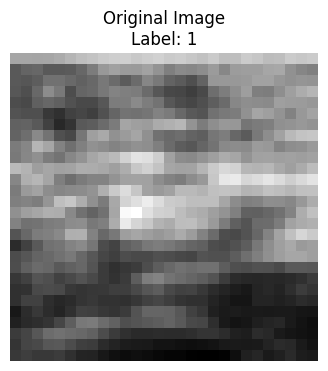

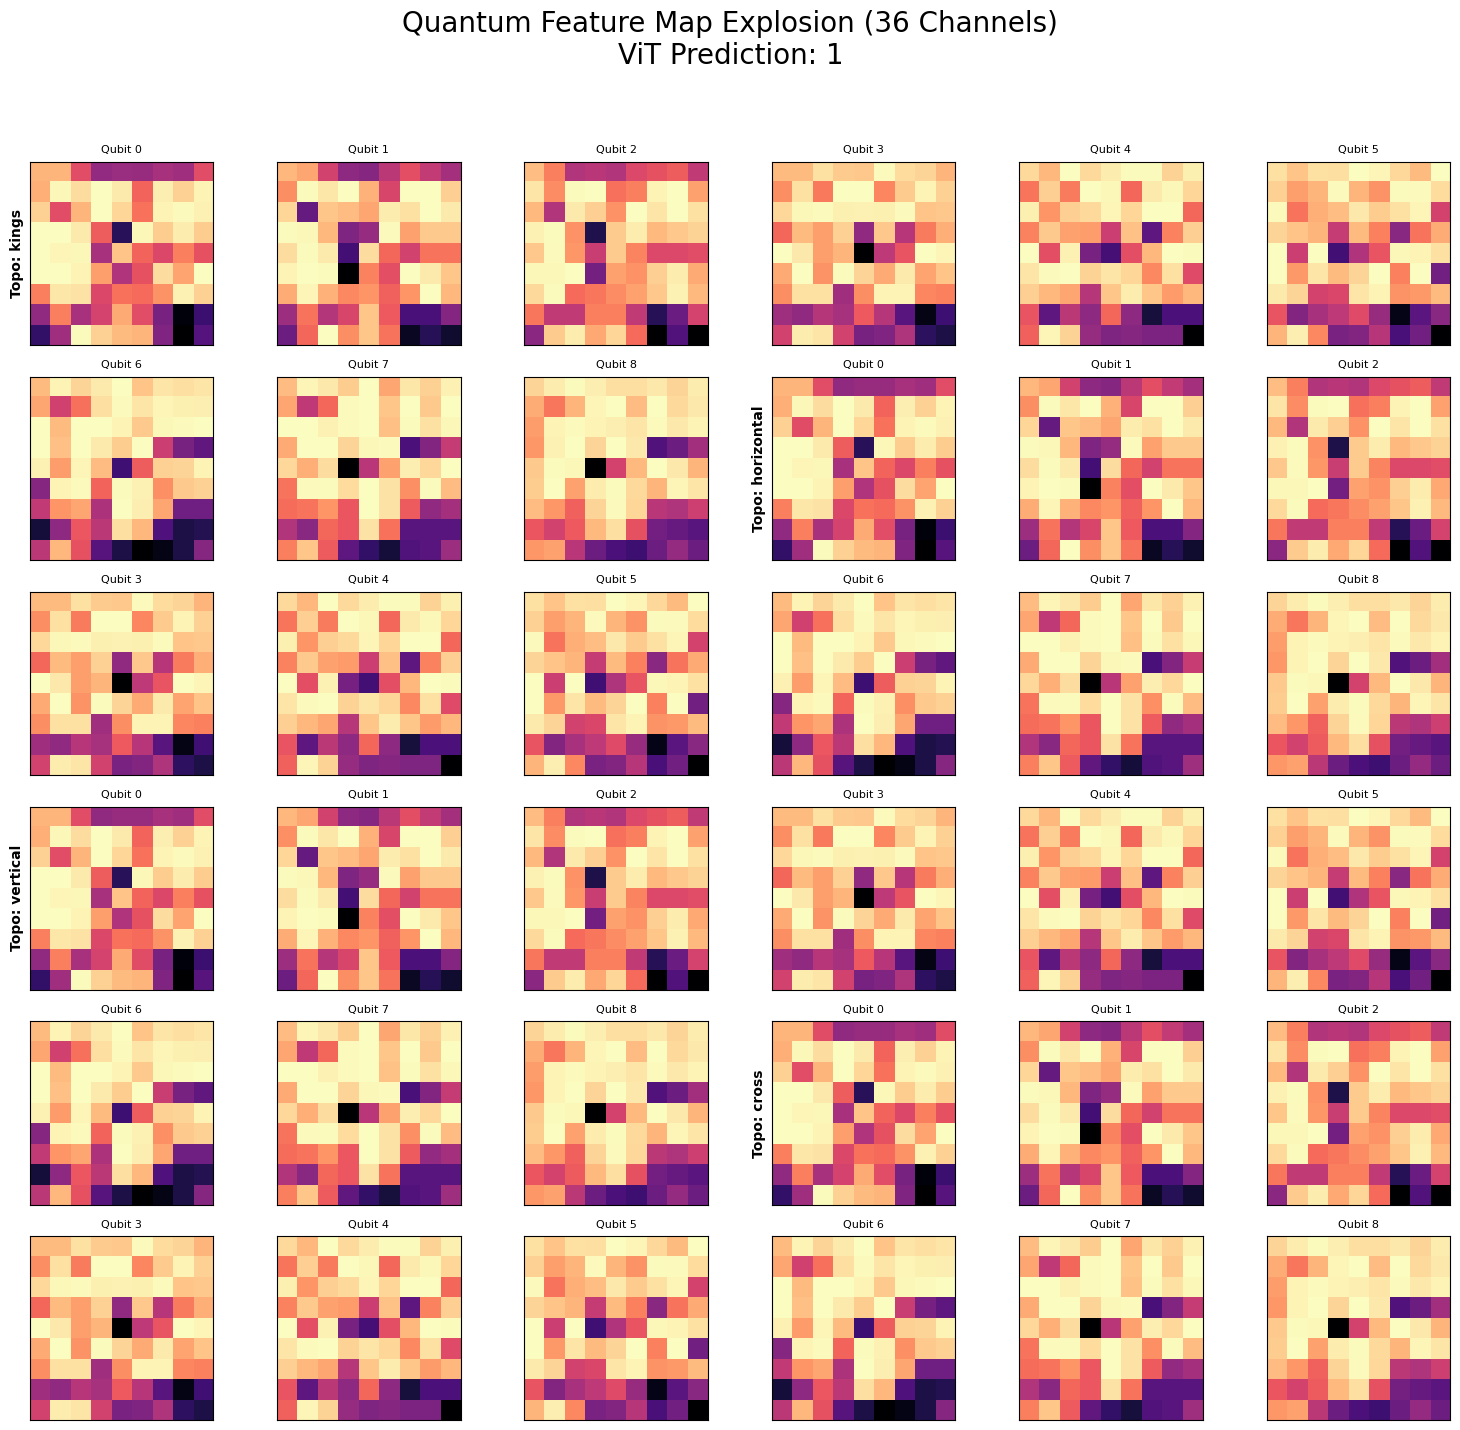

ViT Output Logits: [[-0.30985925  0.02803066]]


In [20]:
# --- PLOT 1: ORIGINAL ---
plt.figure(figsize=(4,4))
plt.imshow(raw_image.squeeze(), cmap='gray')
plt.title(f"Original Image\nLabel: {label.item()}")
plt.axis('off')
plt.show()

# --- PLOT 2: ALL 36 QUANTUM FEATURES ---
fig, axes = plt.subplots(6, 6, figsize=(15, 15))
fig.suptitle(f"Quantum Feature Map Explosion (36 Channels)\nViT Prediction: {prediction.item()}", fontsize=20)

# Topology labels for the rows (9 qubits per topology)
topo_labels = ["Kings", "Horizontal", "Vertical", "Cross"]

for i in range(36):
    ax = axes[i // 6, i % 6]
    img = quantum_features[0, i].cpu().numpy()
    
    # Identify which topology and which qubit this is
    topo_idx = i // 9
    qubit_idx = i % 9
    
    ax.imshow(img, cmap='magma')
    if i % 9 == 0:
        ax.set_ylabel(f"Topo: {TOPOLOGIES[topo_idx]}", fontsize=10, fontweight='bold')
    
    ax.set_title(f"Qubit {qubit_idx}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"ViT Output Logits: {logits.cpu().numpy()}")

In [11]:
# import json
# import os
# import numpy as np
# import torch
# from tqdm import tqdm
# from torch.utils.data import DataLoader
# from datetime import datetime

# # 1. OVERRIDE THE PARAMETERS HERE
# DATASET_NAME = "breast_mnist"
# KERNEL_SIZE = 3
# STRIDE = 3
# # We use only 4 topologies to keep the embedding dim at 36 for our ViT
# KERNEL_TOPOLOGY_NAMES = ["kings", "horizontal", "vertical", "cross"]
# EVOLUTION_TIME = 2.0
# SCALING_FACTOR = 1.0
# BATCH_SIZE = 16 

# # 2. Setup Paths
# data_root = PROJECT_ROOT / "data"
# output_dir = PROJECT_ROOT / "data" / "quantum_datasets"
# output_dir.mkdir(parents=True, exist_ok=True)

# # 3. Initialize the Quantum Layer
# print("Initializing Quantum Layer for BreastMNIST...")
# q_conv = QuantumConv2d(
#     in_channels=1,
#     kernel_size=KERNEL_SIZE,
#     stride=STRIDE,
#     kernel_topology_names=KERNEL_TOPOLOGY_NAMES,
#     scaling_factor=SCALING_FACTOR,
#     evolution_time=EVOLUTION_TIME,
#     quantum_device="default.qubit",
#     interface="torch",
# ).to(device)

# # 4. Processing Loop (Manual version of the script's main)
# results = {}
# for split in ["train", "val", "test"]:
#     print(f"\n--- Processing {split} split ---")
#     ds = load_medmnist_dataset(DATASET_NAME, split, data_root)
#     loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False)
    
#     all_features = []
#     all_labels = []
    
#     for images, labels in tqdm(loader, desc=f"  {split}"):
#         images = images.to(device)
#         with torch.no_grad():
#             # Process and cast to float16 or float32 to save space/matching ViT
#             q_out = q_conv(images).cpu().numpy().astype(np.float32)
        
#         all_features.append(q_out)
#         all_labels.append(labels.numpy().squeeze())

#     results[f"{split}_features"] = np.concatenate(all_features, axis=0)
#     results[f"{split}_labels"] = np.concatenate(all_labels, axis=0)

# # 5. Save the Output
# output_filename = f"breast_mnist_vit_k3_s3_custom.npz"
# output_path = output_dir / output_filename

# np.savez_compressed(
#     output_path,
#     train_features=results["train_features"],
#     train_labels=results["train_labels"],
#     val_features=results["val_features"],
#     val_labels=results["val_labels"],
#     test_features=results["test_features"],
#     test_labels=results["test_labels"]
# )

# print(f"\nSUCCESS! Quantum dataset saved to: {output_path}")
# print(f"Total images processed: {len(results['train_labels']) + len(results['val_labels']) + len(results['test_labels'])}")

In [21]:
class QuantumFeatureDataset(torch.utils.data.Dataset):
    def __init__(self, npz_path, split='train'):
        data = np.load(npz_path, allow_pickle=True)
        # Features are (N, 36, 9, 9), Labels are (N,)
        self.features = torch.from_numpy(data[f'{split}_features']).float()
        self.labels = torch.from_numpy(data[f'{split}_labels']).long()

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

# Path to your newly created file
CACHE_PATH = PROJECT_ROOT / "data" / "quantum_datasets" / "breast_mnist_vit_k3_s3_custom.npz"

train_ds = QuantumFeatureDataset(CACHE_PATH, split='train')
val_ds = QuantumFeatureDataset(CACHE_PATH, split='val')

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_ds, batch_size=32, shuffle=False)

In [22]:
# 1. Initialize Model, Optimizer, and Loss
model = QuantumToViT(num_classes=2).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 500
history = {'train_acc': [], 'val_acc': []}

print(f"Starting Training on {len(train_ds)} Quantum Samples...")

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    model.train()
    train_correct = 0
    for features, labels in train_loader:
        features, labels = features.to(device), labels.to(device)
        
        outputs = model(features)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_correct += (outputs.argmax(1) == labels).sum().item()
    
    # --- VALIDATION PHASE ---
    model.eval()
    val_correct = 0
    with torch.no_grad():
        for features, labels in val_loader:
            features, labels = features.to(device), labels.to(device)
            outputs = model(features)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            
    t_acc = 100 * train_correct / len(train_ds)
    v_acc = 100 * val_correct / len(val_ds)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)
    
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1:02d} | Train Acc: {t_acc:.2f}% | Val Acc: {v_acc:.2f}%")

print("\nTraining Complete!")

Starting Training on 546 Quantum Samples...
Epoch 05 | Train Acc: 75.27% | Val Acc: 75.64%
Epoch 10 | Train Acc: 81.32% | Val Acc: 76.92%
Epoch 15 | Train Acc: 83.15% | Val Acc: 75.64%
Epoch 20 | Train Acc: 82.60% | Val Acc: 75.64%
Epoch 25 | Train Acc: 85.53% | Val Acc: 80.77%
Epoch 30 | Train Acc: 89.01% | Val Acc: 78.21%
Epoch 35 | Train Acc: 87.55% | Val Acc: 79.49%
Epoch 40 | Train Acc: 89.56% | Val Acc: 80.77%
Epoch 45 | Train Acc: 93.04% | Val Acc: 82.05%
Epoch 50 | Train Acc: 92.67% | Val Acc: 87.18%
Epoch 55 | Train Acc: 93.59% | Val Acc: 82.05%
Epoch 60 | Train Acc: 92.86% | Val Acc: 82.05%
Epoch 65 | Train Acc: 96.52% | Val Acc: 82.05%
Epoch 70 | Train Acc: 92.49% | Val Acc: 83.33%
Epoch 75 | Train Acc: 91.21% | Val Acc: 82.05%
Epoch 80 | Train Acc: 96.34% | Val Acc: 87.18%
Epoch 85 | Train Acc: 96.34% | Val Acc: 84.62%
Epoch 90 | Train Acc: 95.24% | Val Acc: 85.90%
Epoch 95 | Train Acc: 94.51% | Val Acc: 83.33%
Epoch 100 | Train Acc: 96.89% | Val Acc: 84.62%
Epoch 105 | Tra

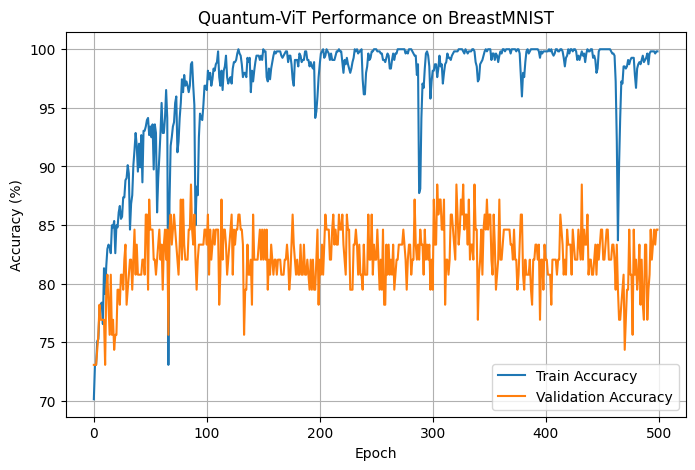

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Quantum-ViT Performance on BreastMNIST')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

In [24]:
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report
import torch.nn.functional as F

# Load the Test Dataset
test_ds = QuantumFeatureDataset(CACHE_PATH, split='test')
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)

In [25]:
model.eval()
all_labels = []
all_preds = []
all_probs = []

print("Evaluating on Test Set...")
with torch.no_grad():
    for features, labels in test_loader:
        features, labels = features.to(device), labels.to(device)
        
        logits = model(features)
        
        # Get probabilities using Softmax
        probs = F.softmax(logits, dim=1)
        
        # We only need the probability of the "Malignant" class (index 1) for AUC
        malignant_probs = probs[:, 1]
        
        preds = torch.argmax(logits, dim=1)
        
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(malignant_probs.cpu().numpy())

# --- CALCULATE METRICS ---
acc = 100 * (np.array(all_preds) == np.array(all_labels)).mean()
auc = roc_auc_score(all_labels, all_probs)

print("-" * 30)
print(f"TEST ACCURACY (ACC): {acc:.3f}%")
print(f"TEST AREA UNDER CURVE (AUC): {auc:.3f}")
print("-" * 30)

Evaluating on Test Set...
------------------------------
TEST ACCURACY (ACC): 78.205%
TEST AREA UNDER CURVE (AUC): 0.778
------------------------------


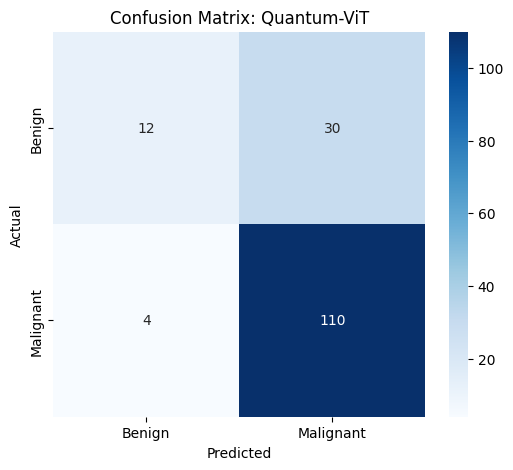


Detailed Classification Report:
              precision    recall  f1-score   support

      Benign       0.75      0.29      0.41        42
   Malignant       0.79      0.96      0.87       114

    accuracy                           0.78       156
   macro avg       0.77      0.63      0.64       156
weighted avg       0.78      0.78      0.74       156



In [17]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Malignant'], 
            yticklabels=['Benign', 'Malignant'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Quantum-ViT')
plt.show()

# Print detailed precision/recall
print("\nDetailed Classification Report:")
print(classification_report(all_labels, all_preds, target_names=['Benign', 'Malignant']))